In [7]:
import struct
import numpy as np
import csv
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import re
from tqdm import tqdm


In [4]:
def read_binary_density_grid(filename):
    with open(filename, "rb") as f:
        # Read grid metadata
        Dim = struct.unpack('i', f.read(4))[0]
        Nx = struct.unpack(f'{Dim}i', f.read(Dim * 4))
        L = struct.unpack(f'{Dim}f', f.read(Dim * 4))
        ntypes = struct.unpack('i', f.read(4))[0]

        # Calculate the total number of grid points
        M = np.prod(Nx)

        # Read density data
        all_rho = np.fromfile(f, dtype=np.float32, count=M * ntypes)
        all_rho = all_rho.reshape((ntypes, M))  # Reshape to (ntypes, M)

        return Dim, Nx, L, ntypes, all_rho

def write_csv_from_density(filename, csv_filename):
    Dim, Nx, L, ntypes, all_rho = read_binary_density_grid(filename)

    # Calculate grid spacings
    dx = [L[i] / Nx[i] for i in range(Dim)]

    # Open CSV file for writing
    with open(csv_filename, mode='w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        
        # Write header
        headers = ['x', 'y', 'z'][:Dim] + [f'rho_{i}' for i in range(ntypes)]
        csvwriter.writerow(headers)

        # Write data
        for i in range(np.prod(Nx)):
            nn = np.unravel_index(i, Nx)  # Get the 3D/2D index
            coords = [nn[j] * dx[j] for j in range(Dim)]
            row = coords + [all_rho[t, i] for t in range(ntypes)]
            csvwriter.writerow(row)
            
def plot_density(csv_file, sigma, ntypes=2, z_slice=30.0):
    # Read the CSV file
    df = pd.read_csv(csv_file)
    
    # If it's a 3D grid, filter by z_slice to plot a 2D slice
    if 'z' in df.columns and z_slice is not None:
        df = df[df['z'] == z_slice]
    
    # Create subplots: one for each molecule type
    fig, axes = plt.subplots(nrows=1, ncols=ntypes, figsize=(8 * ntypes, 8))
    
    for t in range(ntypes):
        ax = axes[t] if ntypes > 1 else axes  # Ensure compatibility for ntypes == 1
        ax.scatter(df['x'], df['y'], c=df[f'rho_{t}'], cmap='Blues', s=1)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(f'Density Type {t}')
        plt.colorbar(ax.collections[0], ax=ax, label='Density')  # Add colorbar to each subplot
    
    plt.suptitle(rf'2D Density Grid Visualization for Each Molecule Type with $\zeta$ = {sigma}')
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit title
    plt.show()

def plot_density_3d(csv_file, sigma, ntypes=2):
    # Read the CSV file
    df = pd.read_csv(csv_file)
    
    # Create subplots: one for each molecule type
    fig = plt.figure(figsize=(10 * ntypes, 8))
    
    for t in range(ntypes):
        ax = fig.add_subplot(1, ntypes, t+1, projection='3d')
        alpha_values = df[f'rho_{t}'].values / df[f'rho_{t}'].max()
        img = ax.scatter(df['x'], df['y'], df['z'], c=df[f'rho_{t}'], cmap='Blues', s=1, alpha=alpha_values)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f'Density Type {t}')
        fig.colorbar(img, ax=ax, label='Density')
    
    plt.suptitle(rf'3D Density Grid Visualization for Each Molecule Type with $\zeta$ = {sigma}')
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit title
    plt.show()


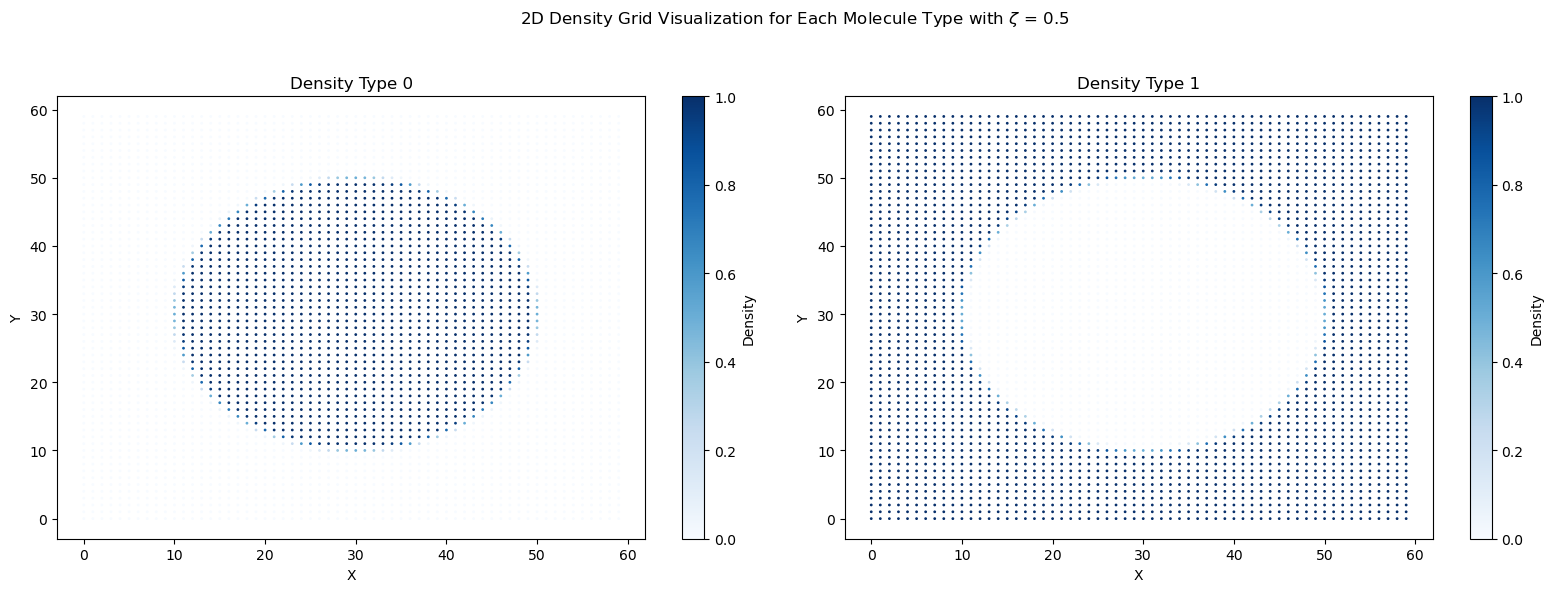

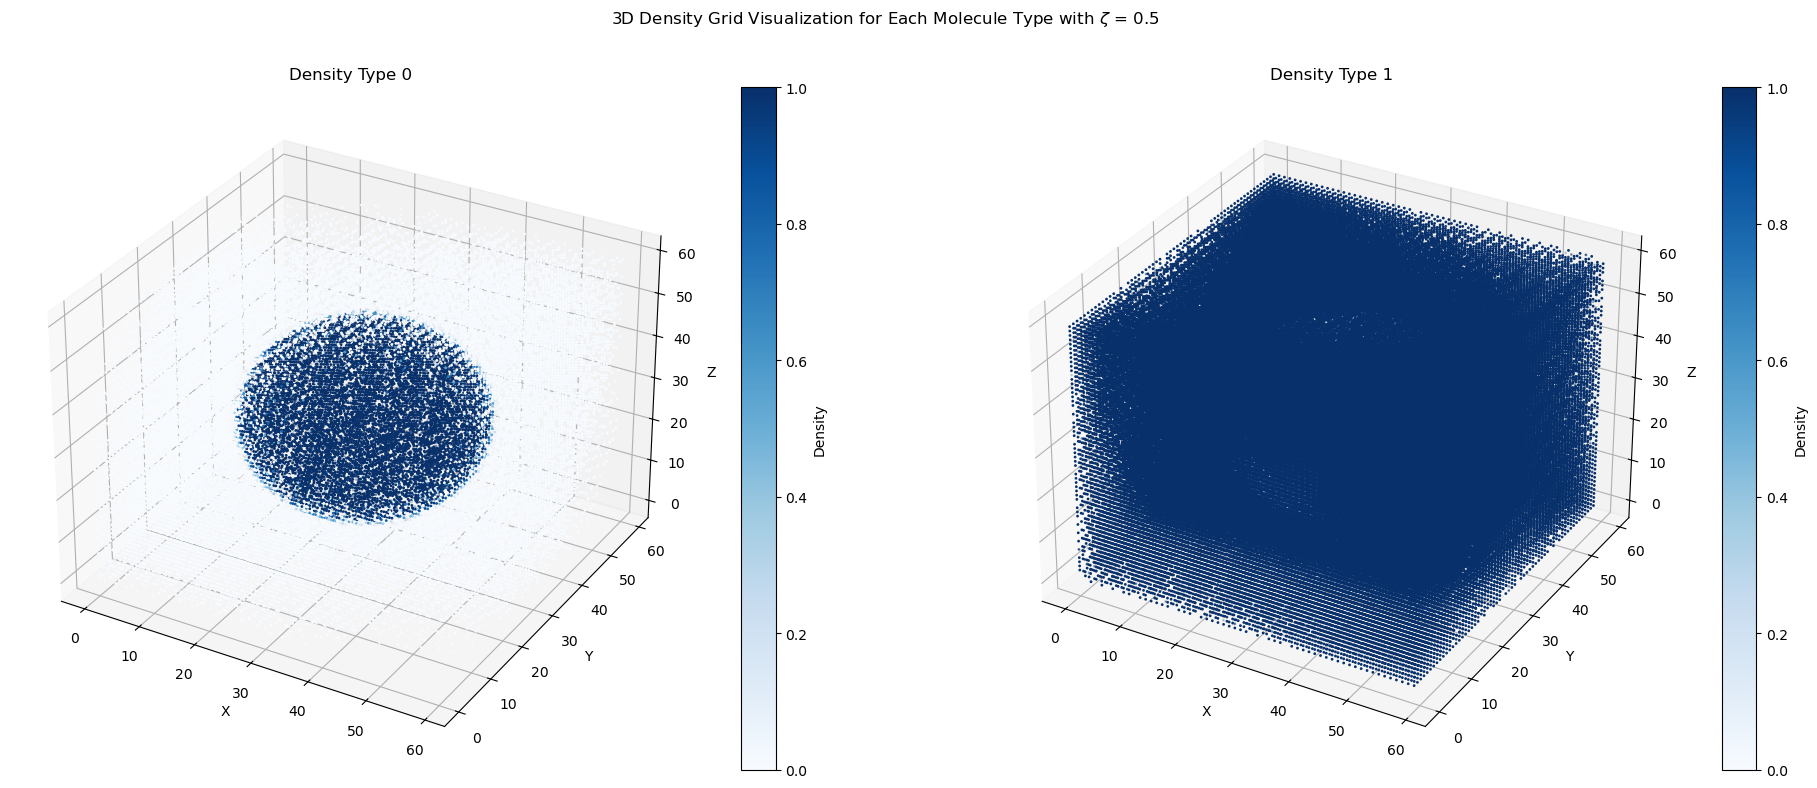

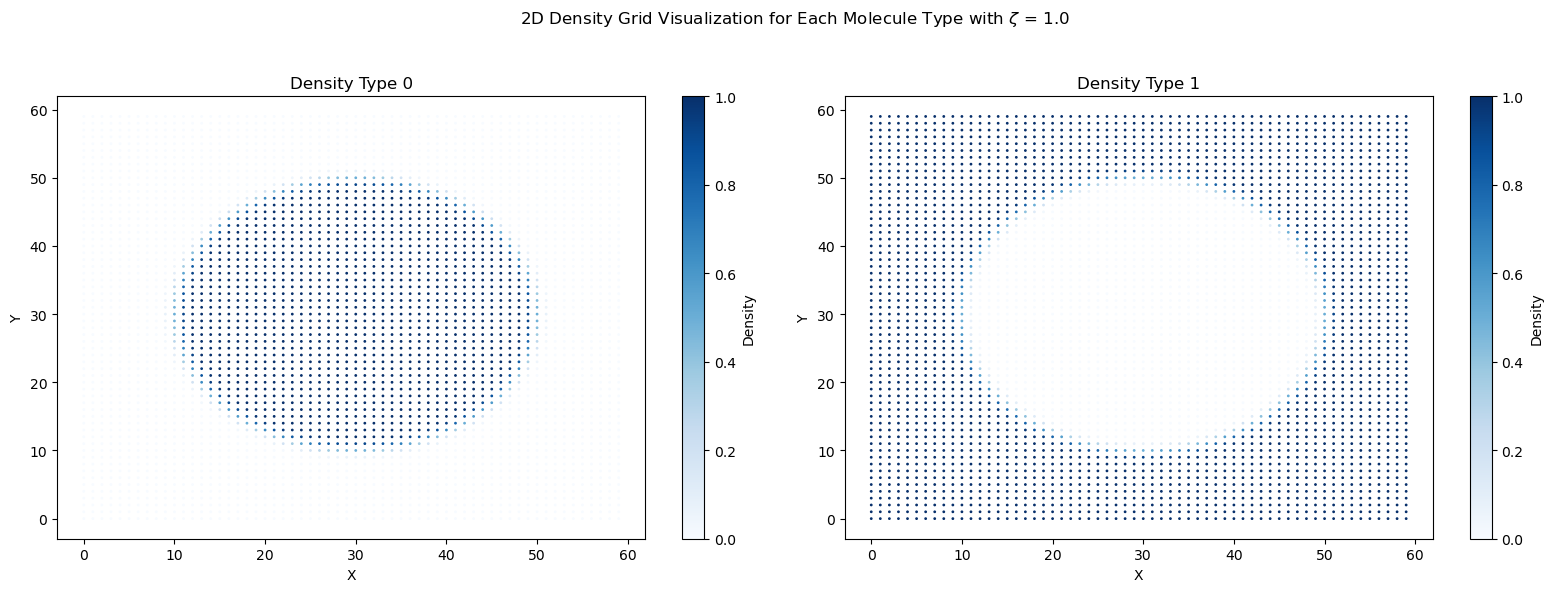

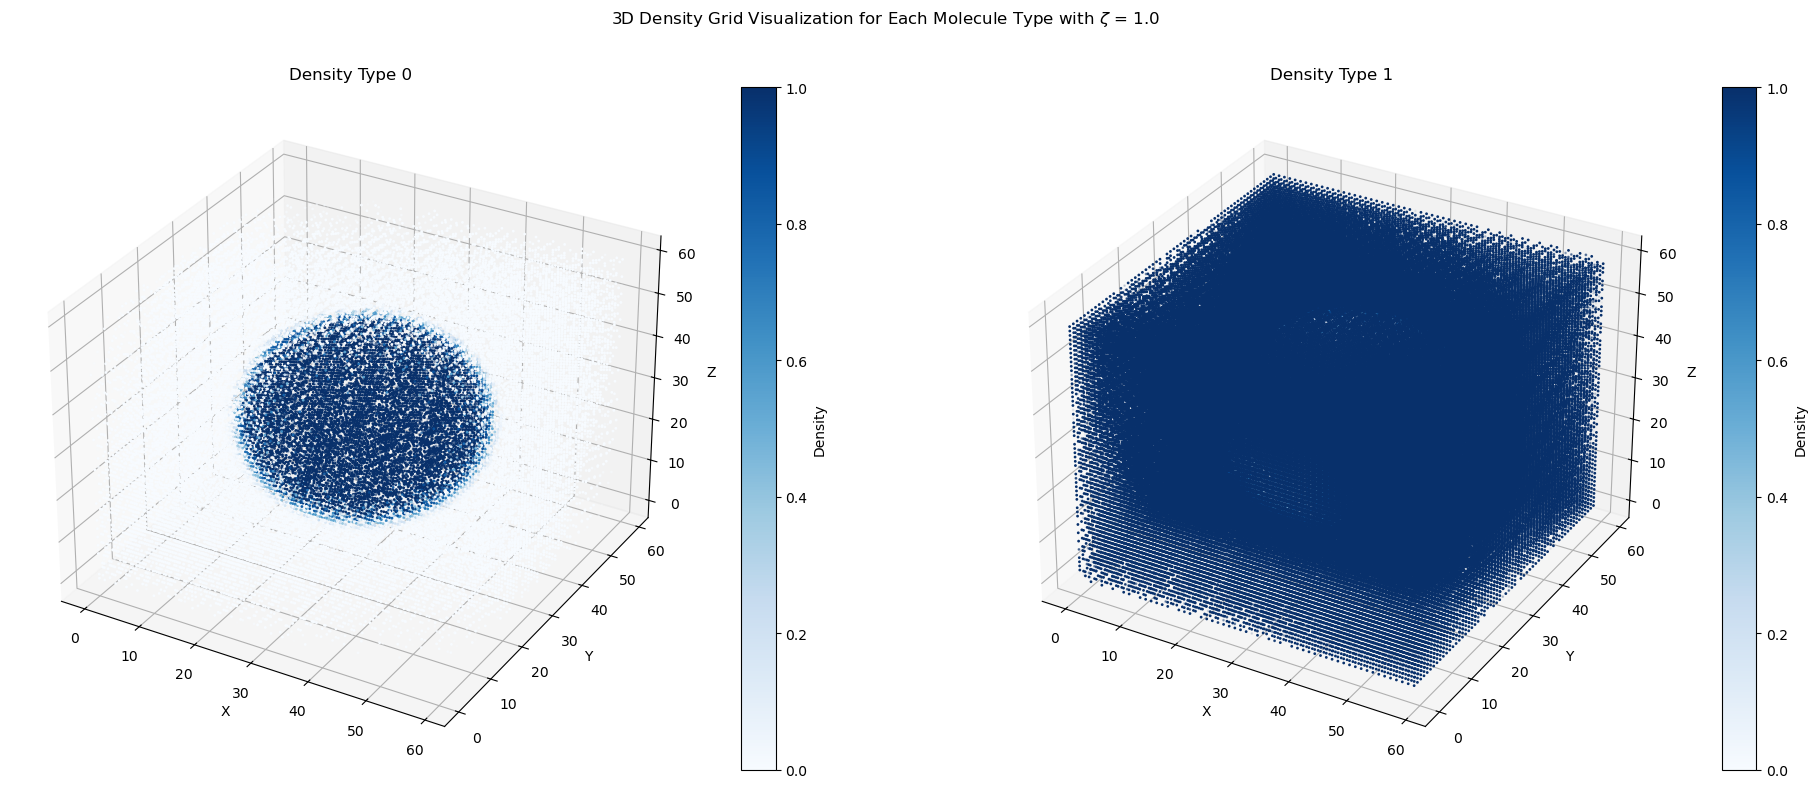

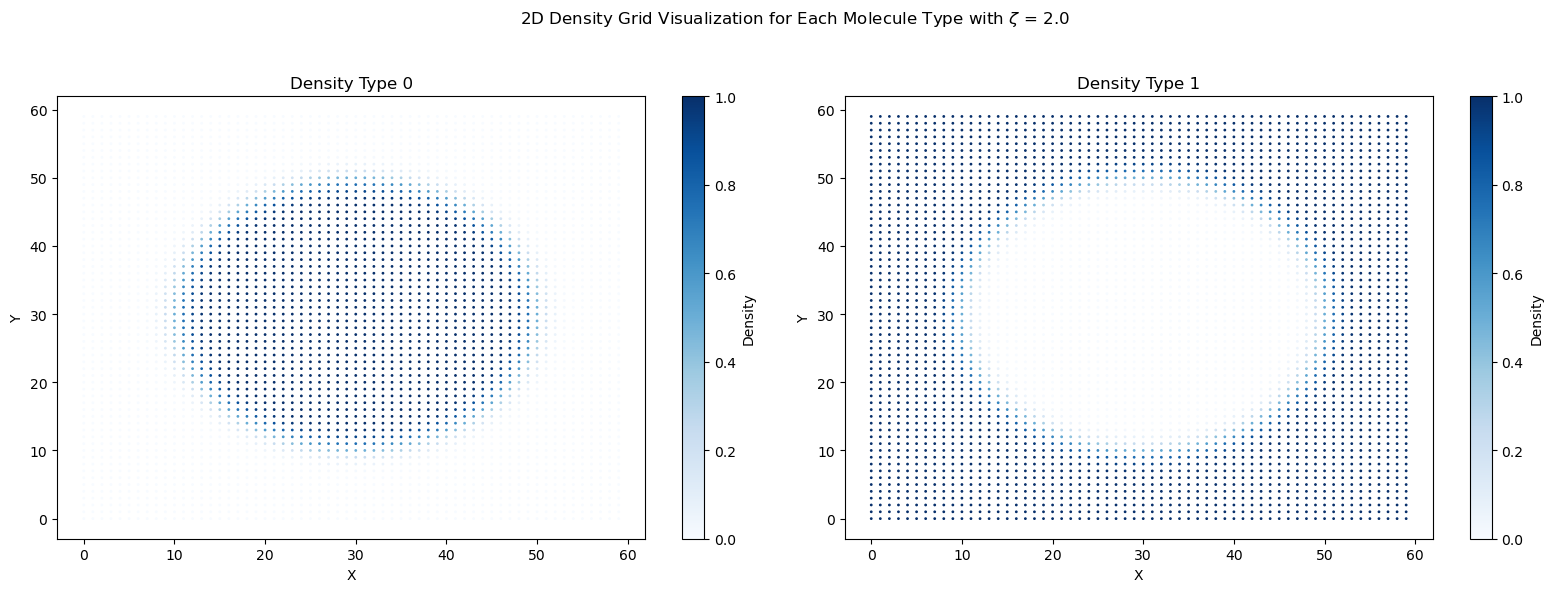

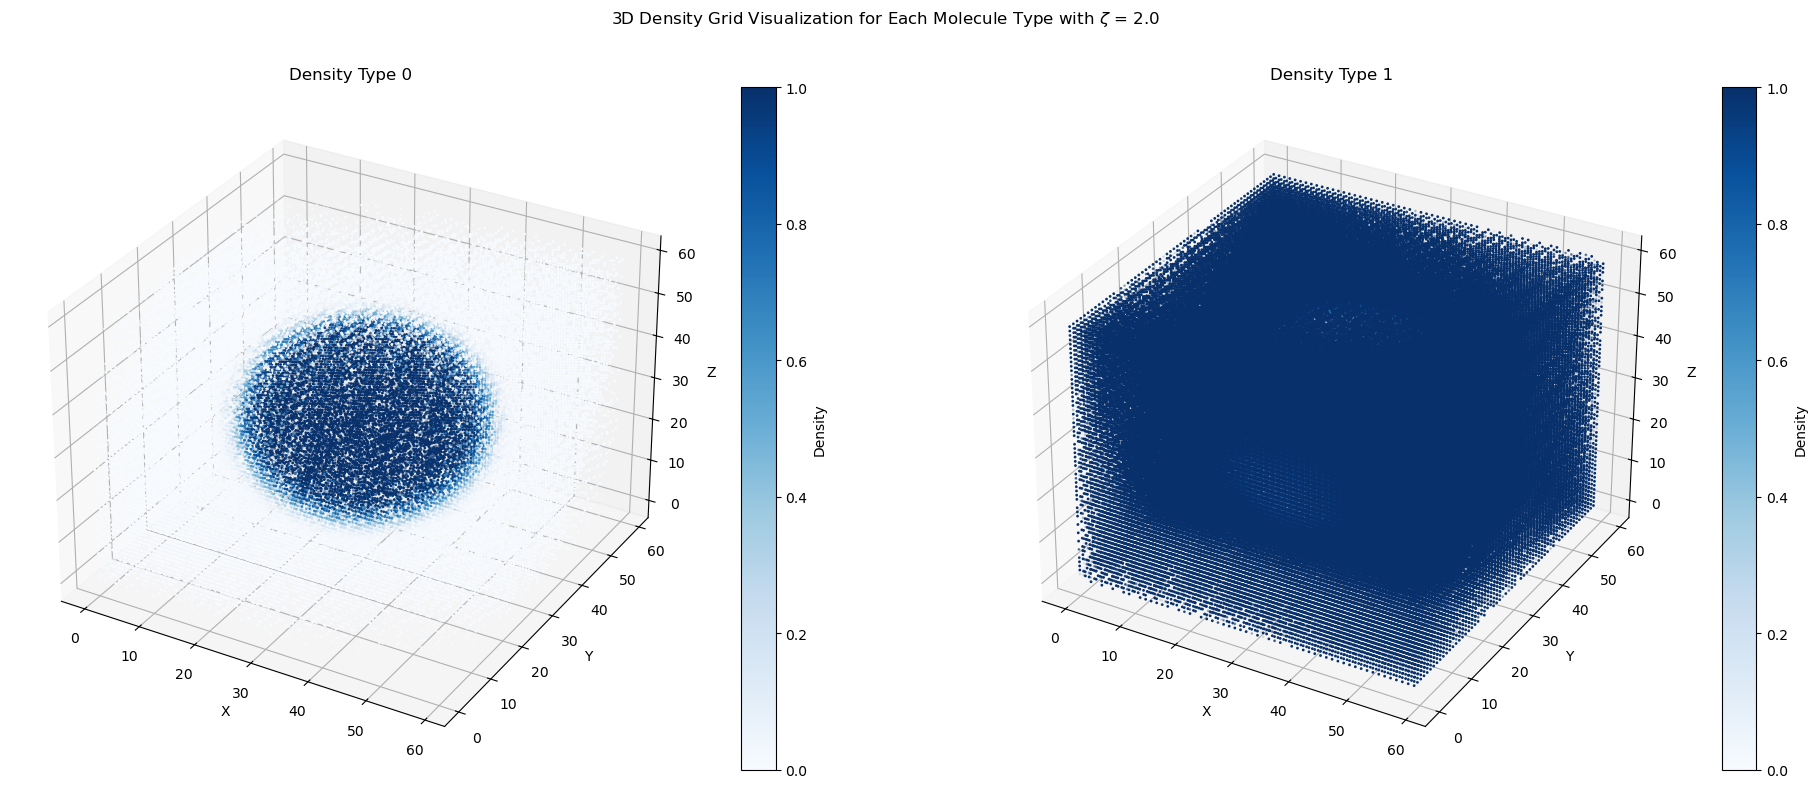

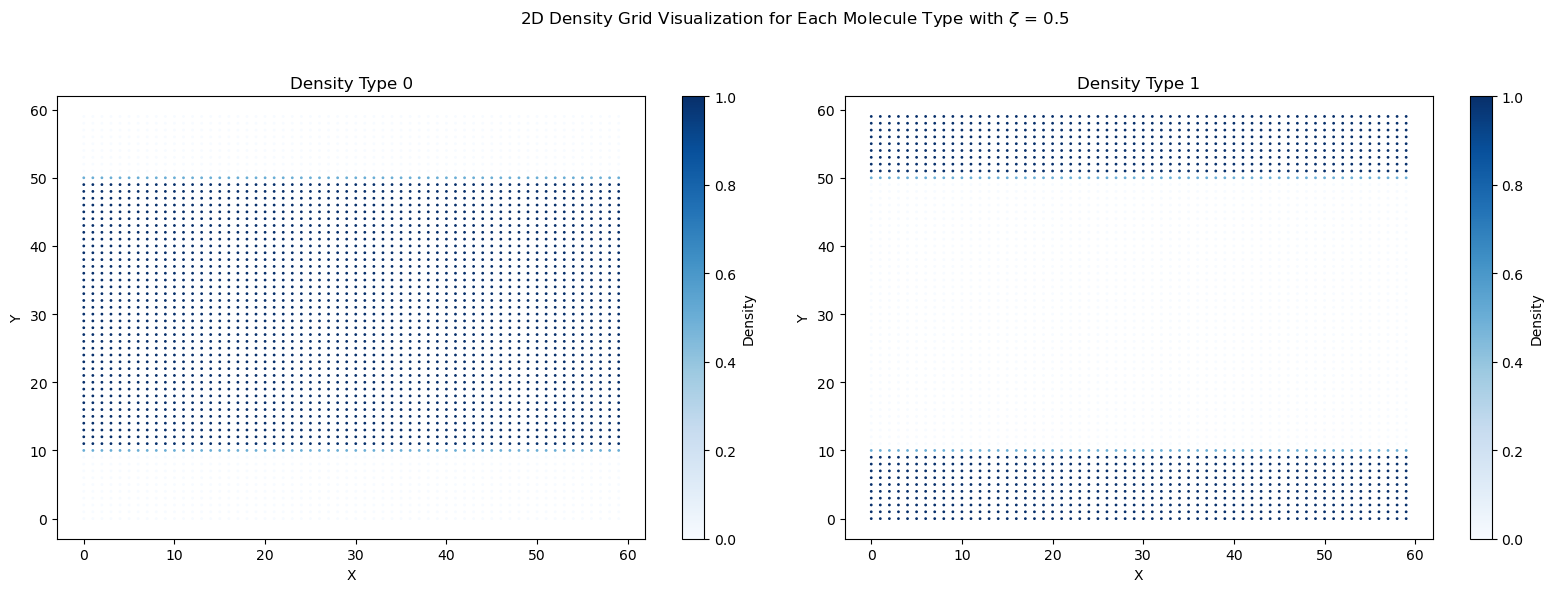

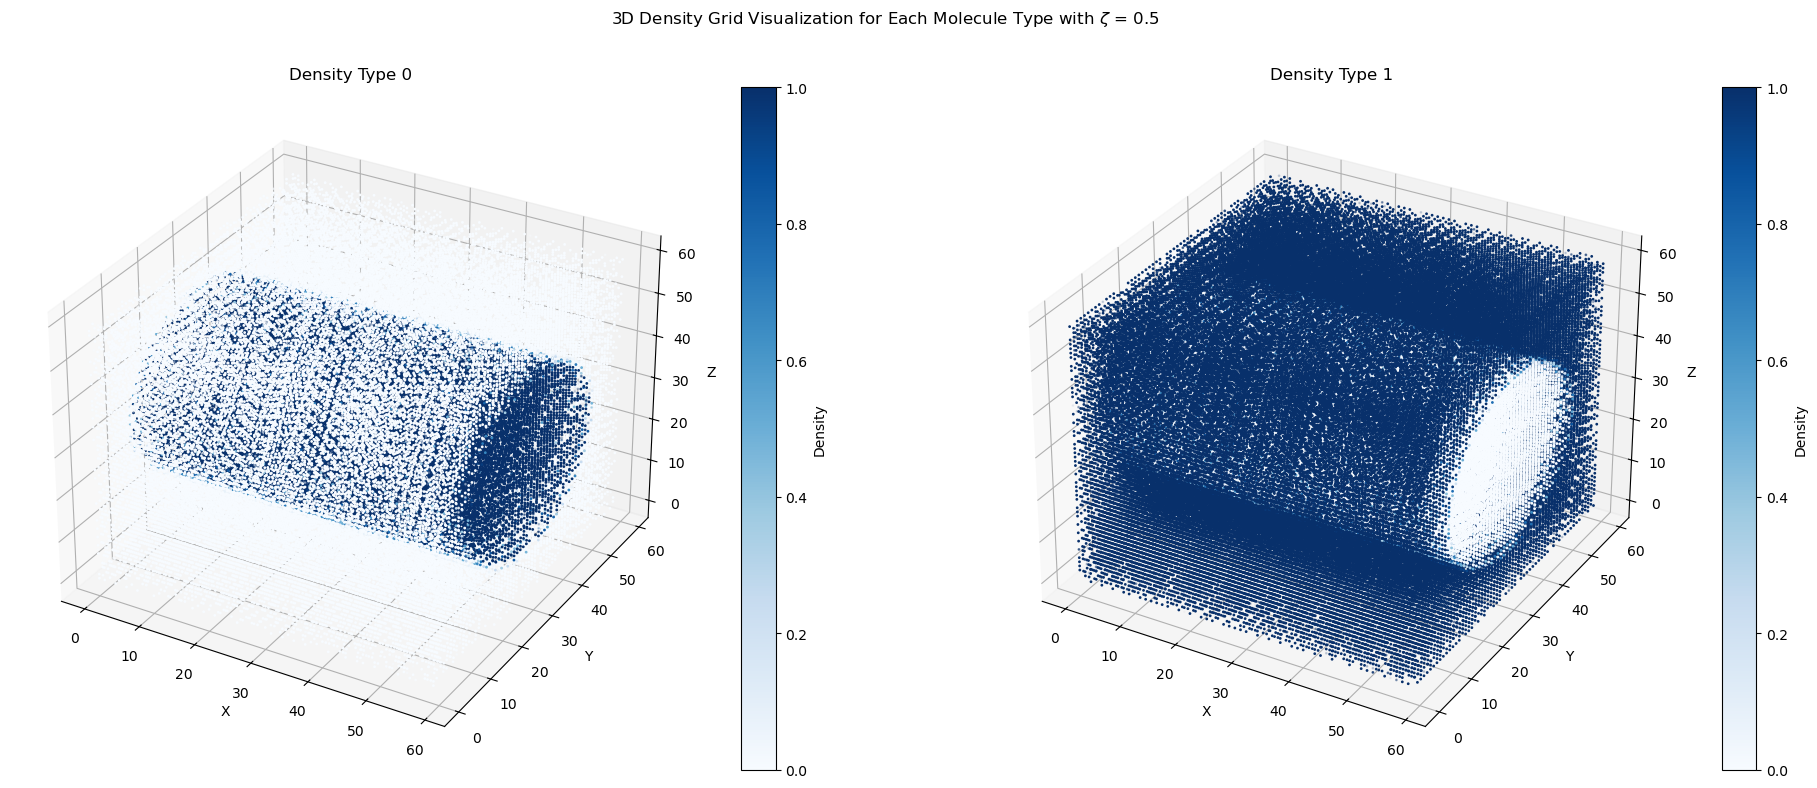

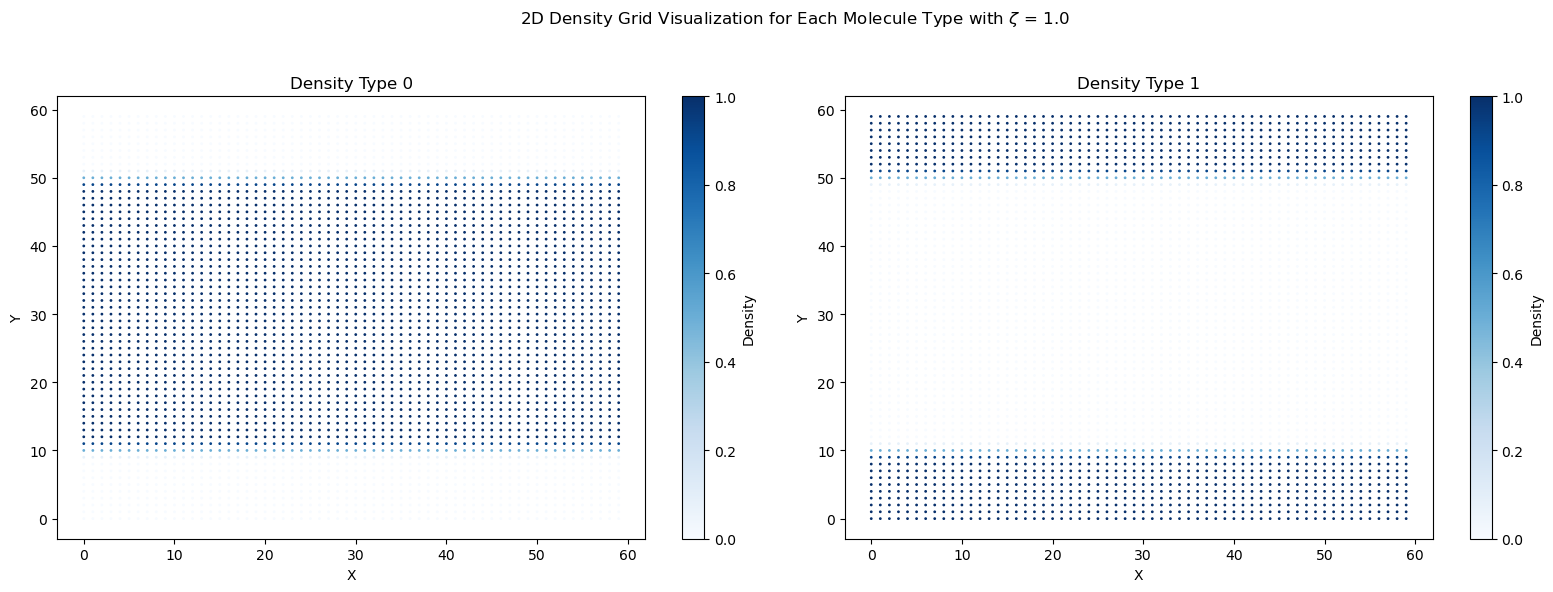

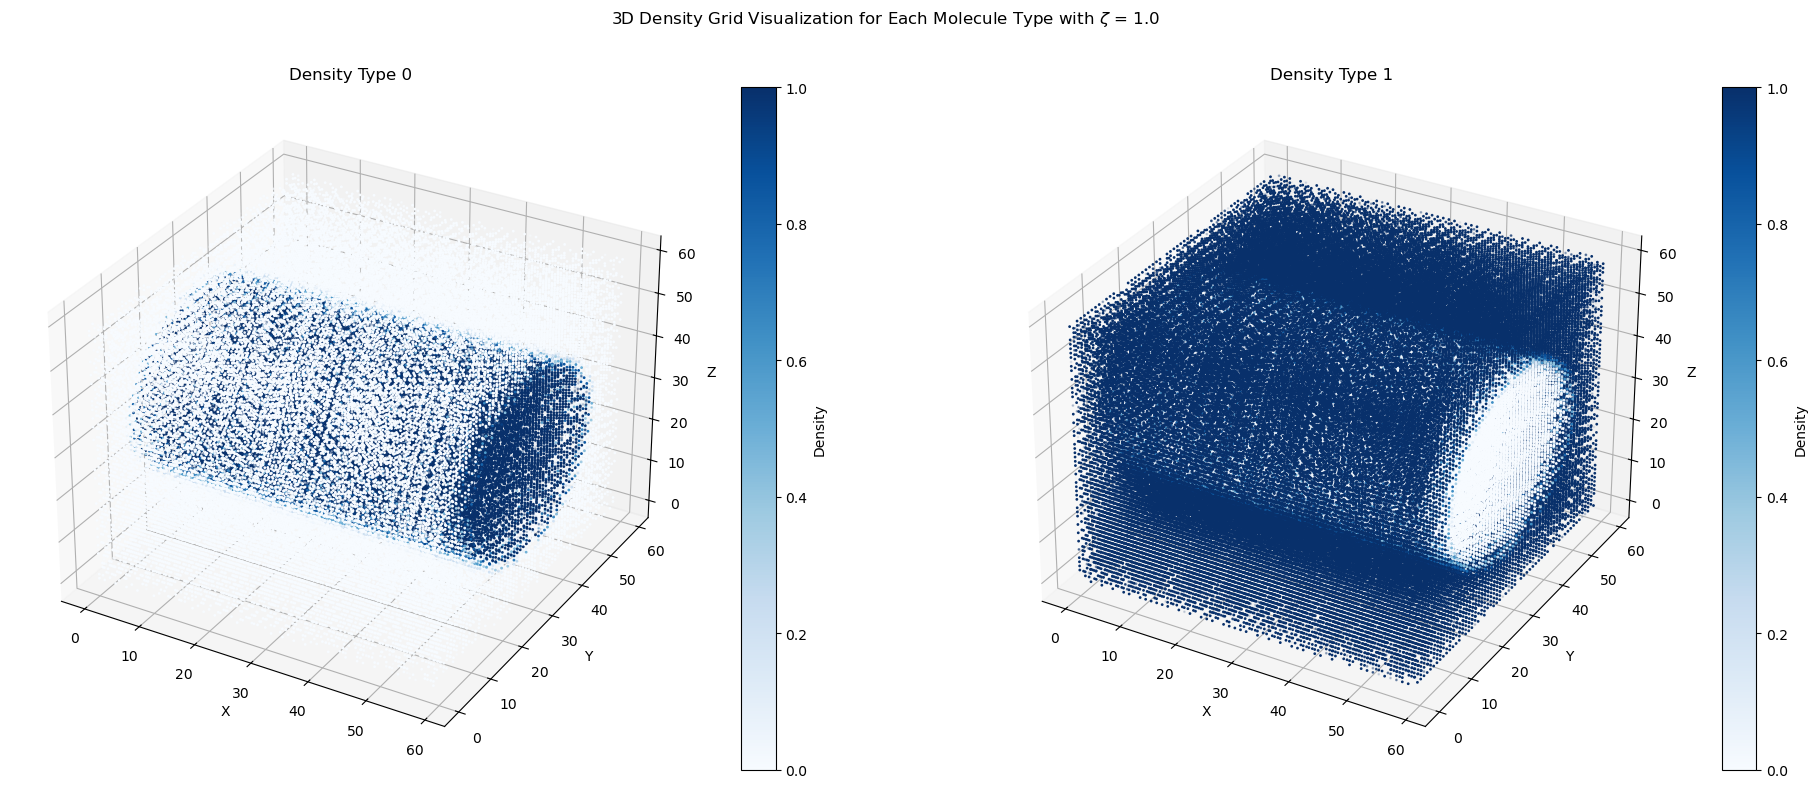

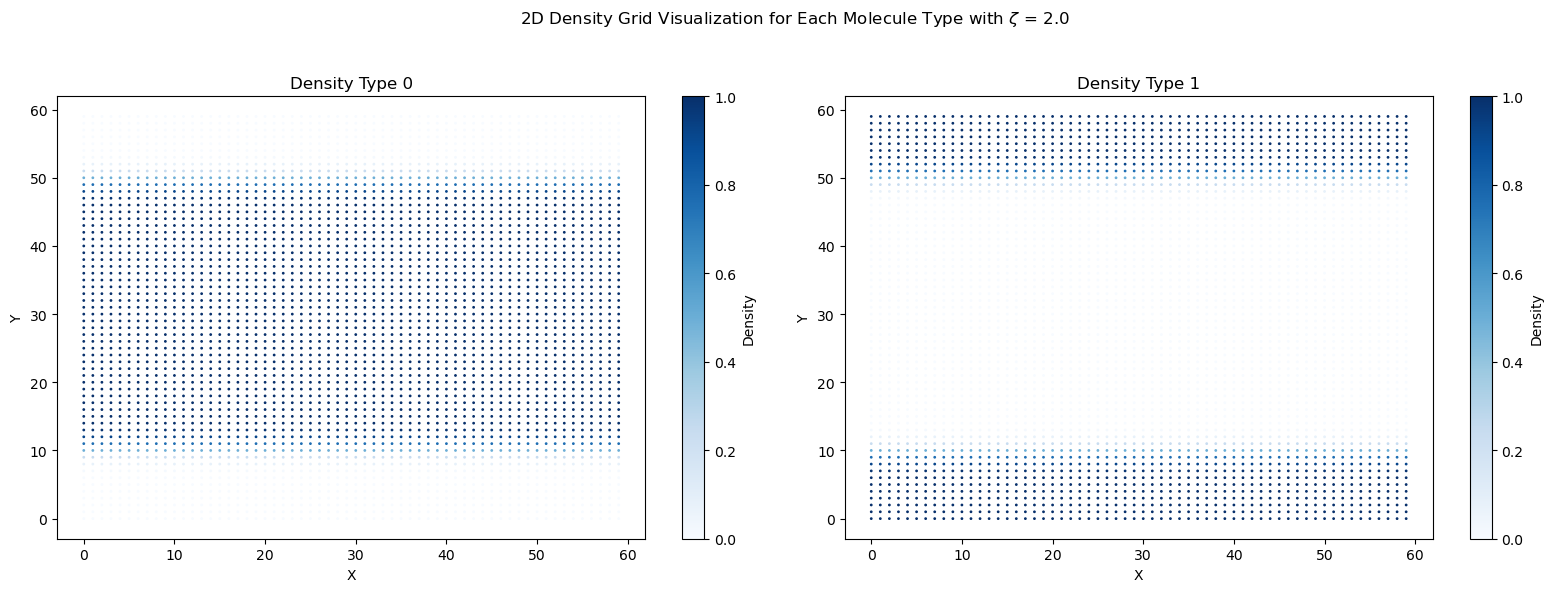

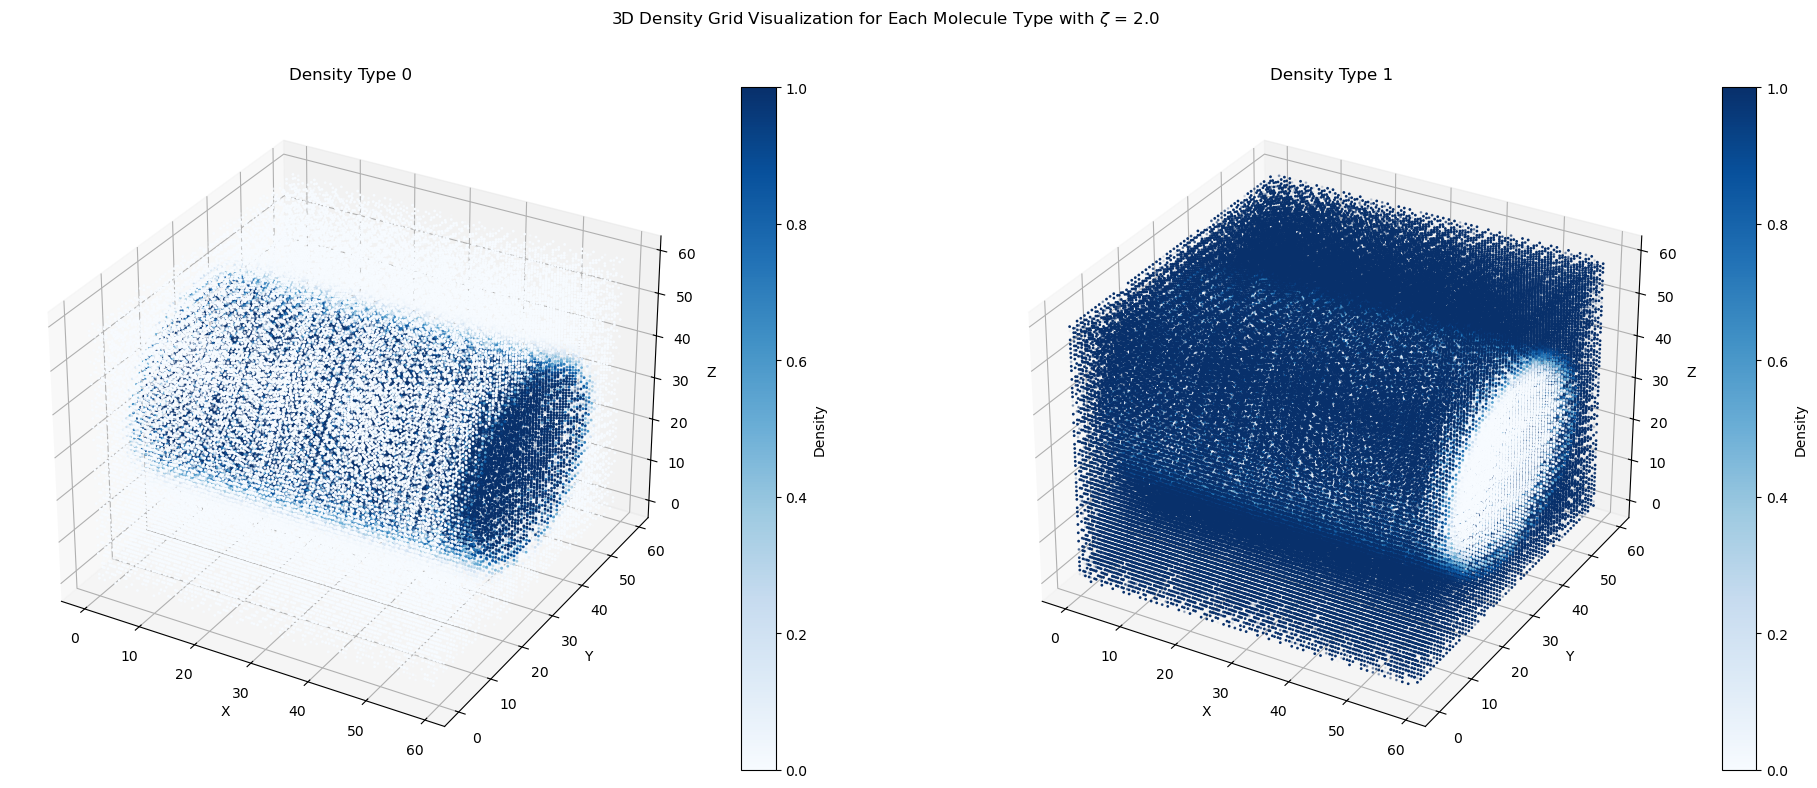

In [9]:
shapes = ['sphere', 'cylinder']
sigmas = ['0.5', '1.0', '2.0']

# Iterate over all combinations of shapes and sigmas
for shape in shapes:
    for sigma in sigmas:
        filename = f"{shape}_density_radius_20.0_sigma_{sigma}.bin"
        csv_filename = f"{shape}_density_radius_20.0_sigma_{sigma}.csv"
        
        # Convert the binary density grid to CSV
        write_csv_from_density(filename, csv_filename)
        
        # Plot the density grid
        plot_density(csv_filename, sigma)
        
        # Plot the 3D density grid
        plot_density_3d(csv_filename, sigma)

In [5]:
import pandas as pd
import numpy as np
import numpy.linalg as la
from skimage.measure import marching_cubes
import math
import glob
import os
import re
import matplotlib as plt
from scipy.interpolate import RegularGridInterpolator
import trimesh
from scipy.signal import fftconvolve, convolve


# Function to recursively search for files within subdirectories
def search_files(directory):
    file_list = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_list.append(os.path.join(root, file))
    return file_list

# Function to parse the filename and extract the particle type, liquid crystal fraction, anchoring strength and repetition
def parse_filename(filename):
    parts = filename.split('_')
    particle_type = parts[2]
    lc_frac = parts[5]
    anch_str = str(parts[8])
    rep = parts[12]
    return  particle_type, lc_frac, anch_str, rep

def parse_filename2(filename):
    parts = filename.split('_')
    particle_type = parts[0]
    lc_frac = parts[2]
    anch_str = str(float(parts[5]))
    frame = parts[7]
    rep = parts[9]
    return  particle_type, lc_frac, anch_str,frame, rep

# Function to extract the frame number from the filename
def extract_frame_number(filename):
    match = re.search(r"_den(\d+).csv$", filename)
    if match:
        return int(match.group(1))
    else:
        return None
    
#Function to interpolate into the 3D matrix
def trilinear_interpolate(F,x,y,z):
   #input : F(Nx,Ny,Nz) is a 3D matrix
   #        (x,y,z) is the coordinates where to estimate F
   i=int(x % F.shape[0]) 
   j=int(y % F.shape[1]) 
   k=int(z % F.shape[2]) 
  
   i_next = (i+1)%F.shape[0]
   j_next = (j+1)%F.shape[1]
   k_next = (k+1)%F.shape[2]
   #print(f"{i_next}, {j_next}, {k_next}")
   Finterp=F[i  ,j  ,k  ]*(i_next-x)*(j_next-y)*(k_next-z) \
          +F[i_next,j  ,k  ]*(x-i)*(j_next-y)*(k_next-z) \
          +F[i  ,j_next,k  ]*(i_next-x)*(y-j)*(k_next-z) \
          +F[i_next,j_next,k  ]*(x-i)*(y-j)*(k_next-z) \
          +F[i  ,j  ,k_next]*(i_next-x)*(j_next-y)*(z-k) \
          +F[i_next,j  ,k_next]*(x-i)*(j_next-y)*(z-k) \
          +F[i  ,j_next,k_next]*(i_next-x)*(y-j)*(z-k) \
          +F[i_next,j_next,k_next]*(x-i)*(y-j)*(z-k)
   return Finterp
# Function to account for periodic boundary conditions
def periodic_boundary(value, min_val, max_val, size):
    while value < min_val:
        value += size
    while value > max_val:
        value -= size
    return value

#Gaussian kernel for smoothing
def gaussian_kernel(sigma, truncate=1.0):
    """
    Returns a Gaussian kernel given a sigma value. The size of the kernel will be truncated
    based on the truncate value.
    """
    lw = int(truncate * sigma + 0.5)
    x = np.linspace(-lw, lw, 2*lw+1)
    y = np.linspace(-lw, lw, 2*lw+1)
    z = np.linspace(-lw, lw, 2*lw+1)

    x, y, z = np.meshgrid(x, y, z, indexing='ij')
    kernel = np.exp(-(x**2 + y**2 + z**2) / (2*sigma**2))
    kernel /= kernel.sum()
    return kernel

from scipy.ndimage import convolve



def gaussian_smoothing_grid_periodic(grid_data, sigma):
    
    # Generate the Gaussian kernel
    kernel = gaussian_kernel(sigma)
    
    # Apply convolution using wrapped boundary conditions
    smoothed_grid = convolve(grid_data, kernel, mode='wrap')
    
    return smoothed_grid

In [8]:
# Get the list of data files
file_directory = "/home/gabriel/MATILDA.FT/utils/post-proc/parallel-curvature-calc"
files =  search_files(file_directory)


#Initialize a dictionary for storing curvature values
data_dict = {}
#pattern = re.compile(r"phase_separation_(smectic|nematic)_lc_frac_0.5_anch_str_(0.0|5.0|-5.0)_Nb_6_rep_(0|1|2)_den022.csv$")
#Testing
pattern = re.compile(r"cylinder_density_radius_20.0_sigma_1.0.csv$")

# Loop over the data files
for file in files:
    filename = os.path.basename(file)
    directory = os.path.dirname(file)
    #pattern = re.compile(r"phase_separation_smectic_lc_frac_0.5_anch_str_5_Nb_6_rep_0_den0(05|10).csv$")

    if pattern.match(filename):
        # Find whether the shape is a sphere or cylinder
        shape = filename.split('_')[0]
        # Find the sigma value
        sigma = filename.split('_')[-1].split('.')[0:1]
        
        # Read the data from the CSV file        
        csv_data = pd.read_csv(file)
        # Extracting data from the dataframe
        X_values = csv_data['x'].values
        Y_values = csv_data['y'].values
        Z_values = csv_data['z'].values

        rho0_values = csv_data['rho_0'].values
        rho1_values = csv_data['rho_1'].values

        # Determine the shape of the grid
        unique_X = np.unique(X_values)
        unique_Y = np.unique(Y_values)
        unique_Z = np.unique(Z_values)

        # Setting up the 3D grid parameters 
        dx, dy, dz = unique_X[1] - unique_X[0], unique_Y[1] - unique_Y[0], unique_Z[1] - unique_Z[0]
        one_dx, one_dy, one_dz = 1./dx, 1./dy, 1./dz
        one_dxdydz = 1./(dx*dy*dz)
        Xmin, Ymin, Zmin = unique_X[0], unique_Y[0], unique_Z[0]
        Nx, Ny, Nz = len(unique_X), len(unique_Y), len(unique_Z)
        box = [Nx*dx, Ny*dy, Nz*dz]

        # Reshaping the density values to fit a 3D grid
        rho0_grid = rho0_values.reshape((Nx, Ny, Nz))
        rho1_grid = rho1_values.reshape((Nx, Ny, Nz))
        volume_fraction = rho0_grid / (rho0_grid + rho1_grid )

        # Smoothing the grid data
        volume_fraction = gaussian_smoothing_grid_periodic(volume_fraction, sigma=1.0)

        # Extracting the isocontour using the Marching Cubes algorithm at volume_fraction = 0.5
        smooth_verts, faces, normals, values = marching_cubes(volume_fraction, 0.5)
        faces = faces.astype(int)
        # Number of points on the isocontour
        Npts = len(smooth_verts)

        # Parameters for the Diffuse Approximation method
        #Nunknw = 10
        Nunknw = 20  # Number of unknowns (10 for 2nd order, 20 for 3rd order, 35 4th order)
        #Nunknw = 35
        Nmin = -3  # Neighbors below along given axis
        Nmax = 3   # Neighbors above along given axis
        Nneigh = (Nmax - Nmin + 1)**3    # Number of neighbors in total

        # Containers for storing curvature values
        mean_curvatures = []
        gauss_curvatures = []

        #Calculate curvature at every vertex
        for idx, vert in enumerate(tqdm(smooth_verts, desc="Calculating Curvatures", unit="vertex")):

            # Extracting origin of vertex coordinates
            Ox, Oy, Oz = vert
            # Initializing matrices
            P = [[0 for a in range(Nunknw)] for b in range(Nneigh)]
            A = np.zeros( (Nunknw,Nunknw) )
            B = np.zeros( (Nunknw,Nneigh) )
            C = np.zeros( (Nunknw) )
            W = np.zeros( (Nneigh) )
            F = np.zeros( (Nneigh) )

            # Neighbor counter
            neigh_count = 0

            # Loop through neighbors of isocontour point
            for k in range(Nmin, Nmax +1):
                b3 = k*dz
                for j in range(Nmin, Nmax +1):
                    b2 = j*dy
                    for i in range(Nmin, Nmax+1):
                        # Distances 
                        b1 =  i*dx
                        # Extract neighbor coordinates while accounting for PBC
                        x = periodic_boundary(Ox + b1, Xmin, Xmin + Nx*dx,  Nx*dx)
                        y = periodic_boundary(Oy + b2, Ymin, Ymin + Ny*dy,  Ny*dy)  
                        z = periodic_boundary(Oz + b3, Zmin, Zmin + Nz*dz,  Nz*dz)

                        #Distance matrix, neighbor value, and weight
                        #P[neigh_count] = [1,b1,b2,b3,b1**2,b2**2,b3**2,b1*b2,b1*b3,b2*b3]    
                        P[neigh_count] = [1,b1,b2,b3,b1**2,b2**2,b3**2,b1*b2,b1*b3,b2*b3, 
                                          b1**3, b2**3, b3**3, b1**2*b2, b1**2*b3, b1*b2**2, b2**2*b3, b1*b3**2, b2*b3**2, b1*b2*b3]
                        #P[neigh_count] = [1,b1,b2,b3,b1**2,b2**2,b3**2,b1*b2,b1*b3,b2*b3, 
                        #                  b1**3, b2**3, b3**3, b1**2*b2, b1**2*b3, b1*b2**2, b2**2*b3, b1*b3**2, b2*b3**2, b1*b2*b3,
                        #                  b1**4, b2**4, b3**4, b1**3*b2, b1**3*b3, b1*b2**3, b2**3*b3, b1*b3**3, b2*b3**3, b1**2*b2**2, b1**2*b3**2, b2**2*b3**2, b1**2*b2*b3, b1*b2**2*b3, b1*b2*b3**2]
                        F[neigh_count] = trilinear_interpolate(volume_fraction, x, y, z)
                        W[neigh_count] = math.exp(-b1**2 -b2**2 -b3**2)
                        neigh_count +=1
            for k in range(0, Nneigh):
                for i in range(0, Nunknw):
                    B[i,k] = B[i,k] + W[k]*P[k][i]
                    C[i] = C[i] +B[i,k]*F[k]
                    for j in range(0,Nunknw):
                        A[i,j] = A[i,j] +P[k][i]*W[k]*P[k][j]
            
            #Solve for partial derivatives
            R = la.solve(A,C)
            Fx = R[1]; Fy = R[2]; Fz = R[3]
            Fxx = R[4]*2; Fyy = R[5]*2; Fzz = R[6]*2
            Fxy = R[7]; Fxz = R[8]; Fyz = R[9]
            
            #Mean Curvature calc based on Eric Albin et al. (2017)
            Num_H = (Fx**2)*(Fyy+Fzz) - 2*Fy*Fz*Fyz +\
                    (Fy**2)*(Fxx+Fzz) - 2*Fx*Fz*Fxz +\
                    (Fz**2)*(Fxx+Fyy) - 2*Fx*Fy*Fxy
            Den_H = (math.sqrt(Fx**2 + Fy**2 + Fz**2))**3
            H = Num_H/(2*Den_H)

            # Gauss Curvature calc based on Eric Albin et al. (2017)
            Num_K = (Fx**2)*(Fyy*Fzz-Fyz**2) + 2*Fz*Fy*(Fxy*Fxz-Fyz*Fxx) + \
                (Fy**2)*(Fxx*Fzz-Fxz**2) + 2*Fx*Fz*(Fxy*Fyz-Fxz*Fyy) + \
                (Fz**2)*(Fxx*Fyy-Fxy**2) + 2*Fx*Fy*(Fxz*Fyz-Fxy*Fzz)
            Den_K = (Fx**2 + Fy**2 + Fz**2)**2
            K = Num_K/Den_K

            mean_curvatures.append(H)
            gauss_curvatures.append(K)

        # Store the curvature values in the dictionary
        frame = extract_frame_number(filename)
        #particle_type, lc_frac, anch_str = parse_filename2(filename)

        data_dict[filename] = {
            "directory": directory,
            "mean_curvature": mean_curvatures, 
            "gauss_curvatures": gauss_curvatures, 
            "vertices": smooth_verts.tolist(),
            "faces": faces.tolist(),
            "shape": shape,
            "zeta": sigma
            }

Calculating Curvatures: 100%|██████████| 9360/9360 [23:08<00:00,  6.74vertex/s]


In [9]:
def scatter_curvature_surface(verts, gaussian_curvatures, mean_curvatures, output_name):
    """
    Visualizes the Gaussian and Mean curvatures at each vertex using scatter plots.
    """
    # Check the range of curvature values
    print("Gaussian Curvature Range:", np.min(gaussian_curvatures), np.max(gaussian_curvatures))
    print("Mean Curvature Range:", np.min(mean_curvatures), np.max(mean_curvatures))
    
    # Keep only the middle 98% of curvature values
    # lower_gauss = np.percentile(gaussian_curvatures, 1)
    # upper_gauss = np.percentile(gaussian_curvatures, 99)
    # lower_mean = np.percentile(mean_curvatures, 1)
    # upper_mean = np.percentile(mean_curvatures, 99)
    
    # gauss_mask = (gaussian_curvatures > lower_gauss) & (gaussian_curvatures < upper_gauss)
    # mean_mask = (mean_curvatures > lower_mean) & (mean_curvatures < upper_mean)
    
    # # Clip the curvature values and vertices
    # gaussian_curvatures = gaussian_curvatures[gauss_mask] 
    # mean_curvatures = mean_curvatures[mean_mask]
    # gauss_verts = verts[gauss_mask]
    # mean_verts = verts[mean_mask]
    gaussian_curvatures = np.array(gaussian_curvatures)
    mean_curvatures = np.array(mean_curvatures)
    verts = np.array(verts)
    # Use a colormap
    colormap = plt.cm.coolwarm
    filename = os.path.basename(output_name)
    shape = re.findall(r'(sphere|cylinder)', filename)
    sigma = re.findall(r'sigma_(\d\.\d+)', filename)

    # Plot 1: Gaussian Curvature Scatter
    fig = plt.figure(figsize=(20, 10))
    ax1 = fig.add_subplot(121, projection='3d')
    scatter_gauss = ax1.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=gaussian_curvatures, cmap=colormap, marker='o', s=5, vmin=-2, vmax=2) 
    fig.colorbar(scatter_gauss, ax=ax1, shrink=0.5, aspect=5)
    ax1.set_title(rf'Gaussian Curvature: {shape}, $\zeta$ = {sigma}')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_xlim(0, 60)
    ax1.set_ylim(0, 60)
    ax1.set_zlim(0, 60)
    
    # Plot 2: Mean Curvature Scatter
    ax2 = fig.add_subplot(122, projection='3d')
    scatter_mean = ax2.scatter(verts[:, 0], verts[:, 1], verts[:, 2], c=mean_curvatures, cmap=colormap, marker='o', s=5, vmin=-1, vmax=1)
    fig.colorbar(scatter_mean, ax=ax2, shrink=0.5, aspect=5)
    ax2.set_title(rf'Mean Curvature: {shape}, $\zeta$ = {sigma}')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    ax2.set_xlim(0, 60)
    ax2.set_ylim(0, 60)
    ax2.set_zlim(0, 60)
    plt.tight_layout()
    plt.show()   
def plot_curvature_histogram(gaussian_curvatures, mean_curvatures, output_name):
    """
    Plots histograms of the Gaussian and mean curvature.
    """
    # Print the amount of curvature values
    print("Gaussian Curvature Count:", len(gaussian_curvatures))
    print("Mean Curvature Count:", len(mean_curvatures))
    gaussian_curvatures = np.array(gaussian_curvatures)
    mean_curvatures = np.array(mean_curvatures)
    lower_gauss = np.percentile(gaussian_curvatures, 1)
    upper_gauss = np.percentile(gaussian_curvatures, 99)
    lower_mean = np.percentile(mean_curvatures, 1)
    upper_mean = np.percentile(mean_curvatures, 99)
    
    gauss_mask = (gaussian_curvatures > lower_gauss) & (gaussian_curvatures < upper_gauss)
    mean_mask = (mean_curvatures > lower_mean) & (mean_curvatures < upper_mean)
    # Print the amount of curvature values after clipping
    print("Gaussian Curvature Count (Clipped):", len(gaussian_curvatures[gauss_mask]))
    print("Mean Curvature Count (Clipped):", len(mean_curvatures[mean_mask]))
    clipped_gauss_curv = gaussian_curvatures[gauss_mask] 
    clipped_mean_curv = mean_curvatures[mean_mask]
    # Find file parameters
    filename = os.path.basename(output_name)
    shape = re.findall(r'(sphere|cylinder)', filename)
    sigma = re.findall(r'sigma_(\d\.\d+)', filename)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    
    gauss_curv_values, gauss_curv_bin_edges = np.histogram(clipped_gauss_curv, bins=100, range = (-.1, .1), density=True)
    gauss_bin_centers = 0.5*(gauss_curv_bin_edges[1:] + gauss_curv_bin_edges[:-1])

    axs[0].semilogy(gauss_bin_centers, gauss_curv_values, color='firebrick',linestyle= '-', marker = "o", alpha=0.7)
    axs[0].set_title(rf'Gaussian Curvature: {shape}, $\zeta$ = {sigma}')
    axs[0].set_xlabel('Gaussian Curvature')
    axs[0].set_ylabel('Frequency')
        
    mean_curv_values, mean_curv_bin_edges = np.histogram(clipped_mean_curv, bins=50, range = (-0.25, .25), density=True)
    mean_bin_centers = 0.5*(mean_curv_bin_edges[1:] + mean_curv_bin_edges[:-1])
    
    
    axs[1].semilogy(mean_bin_centers, mean_curv_values, color='teal',linestyle= '-', marker = "o", alpha=0.7)
    axs[1].set_title(rf'Mean Curvature: {shape}, $\zeta$ = {sigma}')
    axs[1].set_xlabel('Mean Curvature')
    axs[1].set_ylabel('Frequency')
    


    plt.tight_layout()
    plt.show()

Gaussian Curvature Range: -4.830073000999155e-16 0.06512978927844876
Mean Curvature Range: -0.10835838125373339 1.0719885399126887


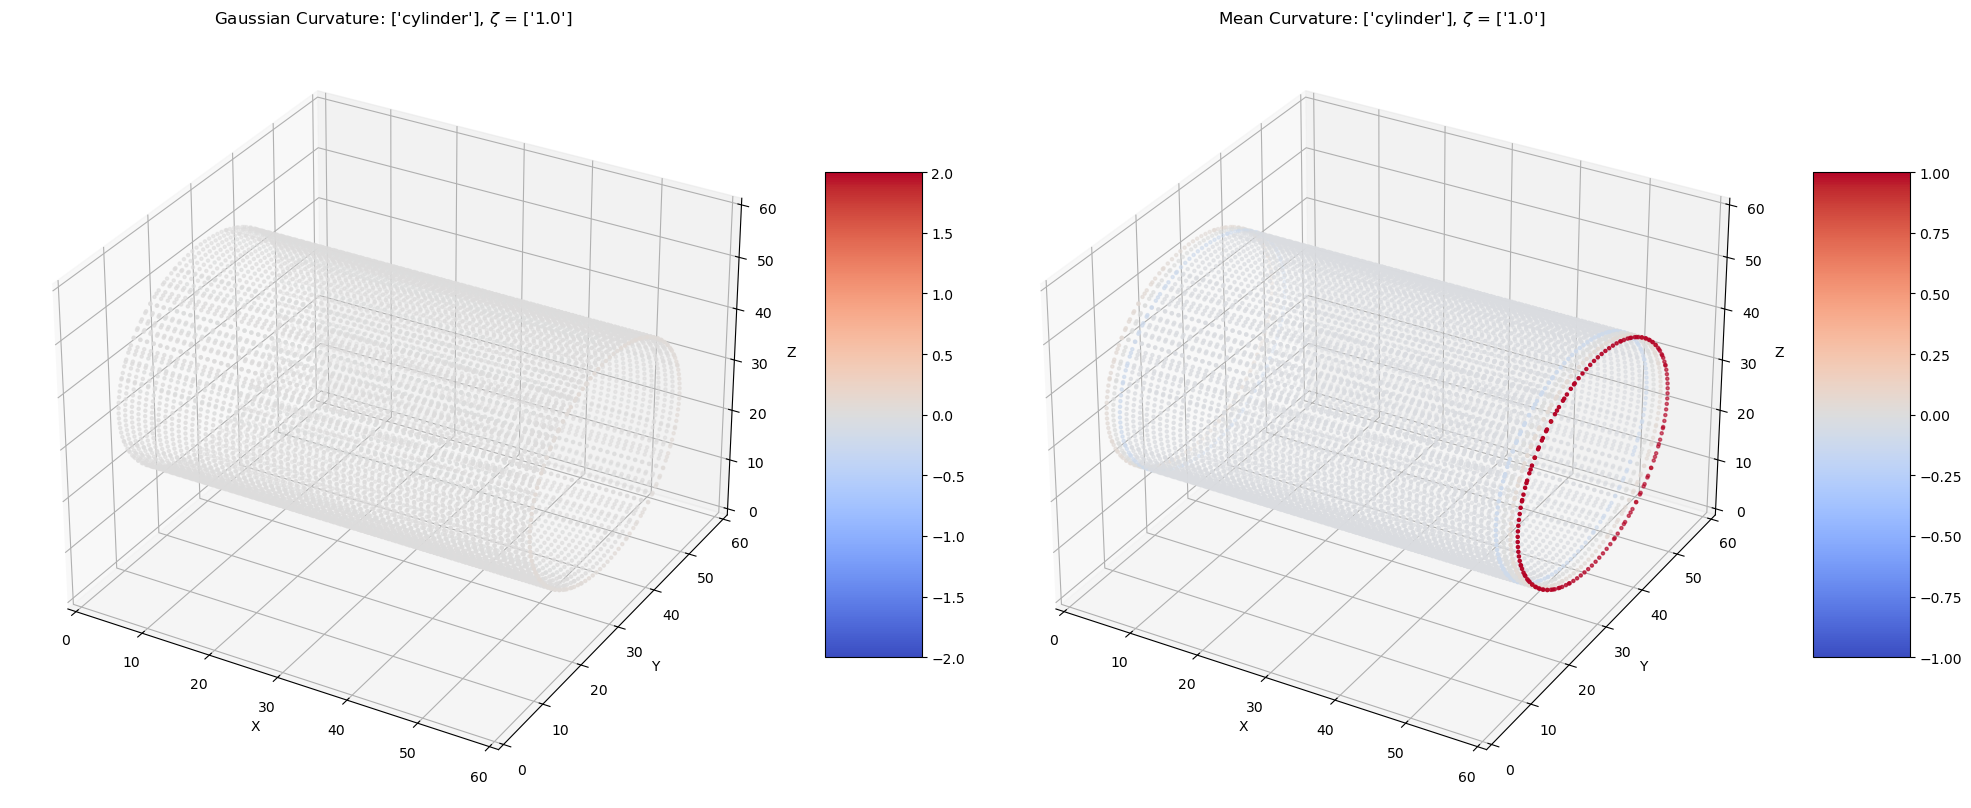

Gaussian Curvature Count: 9360
Mean Curvature Count: 9360
Gaussian Curvature Count (Clipped): 9160
Mean Curvature Count (Clipped): 9171


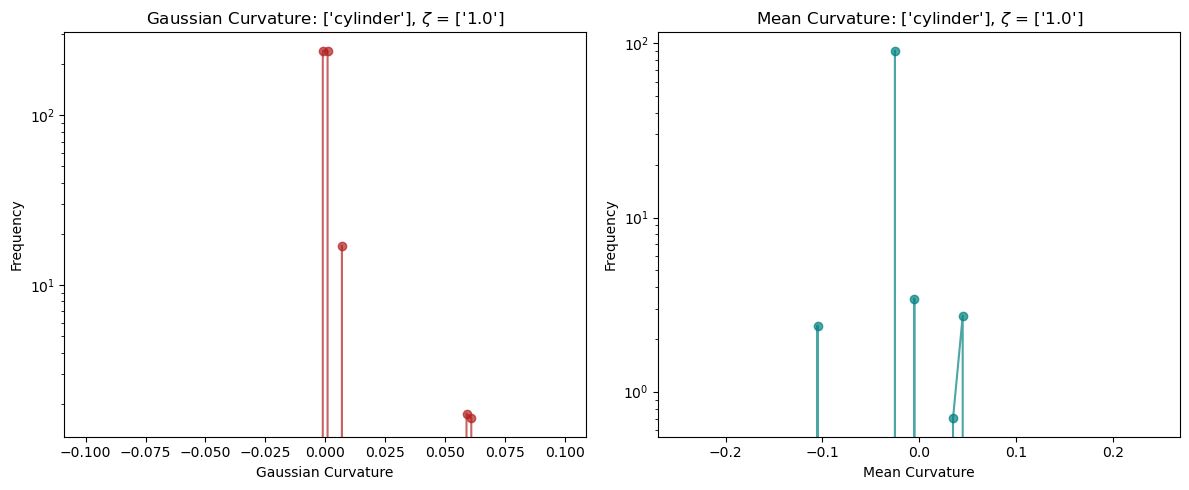

In [10]:
import matplotlib.pyplot as plt
# Plot the mean curvature and Gauss curvature using plotting functions

for key, value in data_dict.items():
    scatter_curvature_surface(value["vertices"], value["gauss_curvatures"], value["mean_curvature"], key)
    plot_curvature_histogram(value["gauss_curvatures"], value["mean_curvature"], key)
